# FX Screener — Pillar Explorer
Run the **Setup** cell once. All other cells are independent after that.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
# import bbg

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Raw Bloomberg data → .cache/ (parquet files) per day we only have a call on the delta of dates (this makes the BBG calls very small)
# To see the data:                                                                                                                                                                                                                                         
#       - ex.to_excel("screener_Monday.xlsx") → composite + all pillars (one sheet each) + score history                                                                                                                                                                    
#       - ex.to_excel_raw("raw_data.xlsx") → all raw Bloomberg panels in native units 
import explore as ex
s = ex.load()

C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
1 tickers unresolved — pill

<Session pillars=7/7  currencies=26  dates=2012-01-02->2026-09-02  FAILED=1>


C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
1 tickers unresolved — pillars renormalised over survivors. Run `python bbg.py --validate` for details.


<Session pillars=7/7  currencies=26  dates=2012-01-02->2026-09-01  FAILED=1>


# Step 0 — The normalisation pipeline.                                                                                                                 
Every raw metric goes through the same three steps before it can be combined with anything else:                                                       
  1. Winsorise — clip to ±3σ of the full sample (kills outlier datapoints that would otherwise dominate a z-score)                                     
  2. Time-series z-score (TS-z) — rolling 1260-day (5y) window: (value − rolling_mean) / rolling_std → answers "is this rich/cheap vs its own history?"                                                                                                               
  3. Cross-sectional z-score (XS-z) — within each bloc (G10 / LATAM / CEEMEA / APAC), across currencies, each day → answers "is this the best available today?"
  4. Blend — 50% TS-z + 50% XS-z (configurable via XS_TS_BLEND)
  5. Clip again to ±3σ

  Result is always in sigma units: positive = attractive long, negative = attractive short.

# Pillar 1 — Trend

  Vol-normalised price momentum at three horizons, plus distance from trend and MACD.

  All sub-signals are divided by 3m realised vol before normalising, so a 5% move in a 20-vol currency and a 5% move in a 10-vol currency get equal weight.

| Sub-signal | What it measures | Weight |
|---|---|---|
| m3 | 63-day log return / RV | 1.5 |
| m6 | 126-day log return / RV | 1.5 |
| m9 | 189-day log return / RV | 1.0 |
| dist_126d | (spot / 126d MA − 1) / RV — distance from 6m moving average | 1.0 |
| macd_hist | (EMA12 − EMA26 − signal9) / spot / RV | 0.5 |

  Short/medium-term momentum is double-weighted; MACD is half-weighted (it's the fastest and noisiest).

 # Pillar 2 — Value

  Two rolling fair-value models: one financial, one fundamental. Both are OLS residuals refitted every 5 business days on a strictly backward-looking window — no lookahead.

  **STEER-lite (2-year window)** — short-horizon financial fair value:
  log(spot) ~ 2y rate diff + log(ToT) + HY OAS risk proxy
  Residual > 0 → spot above fair value → currency is overvalued → score = −residual

  **BEER-lite (5-year window)** — medium-horizon fundamental fair value:
  log(REER) ~ real rate diff + log(ToT) + current account % GDP
  Same sign convention. Equally weighted with STEER.

  Three regressors each is intentional — more regressors buy in-sample fit and sell out-of-sample signal.

# Pillar 6 — Positioning
 Contrarian at extremes. Crowded longs score negative.
  For CoT currencies (G10 + MXN, BRL, ZAR):
| Sub-signal | What it measures | Weight |
|---|---|---:|
| cot_level | Net non-commercial position (L − S) — direction | 1.0 |
| cot_change | 63-day change in net — still building? More dangerous | 0.5 |
| cot_skew | Net / OI — removes noise from absolute OI changes, ranges −1 to +1 | 1.0 |

  For non-CoT currencies (rest of EM):
| Sub-signal | What it measures | Weight |
|---|---|---:|
| skew | 25d risk reversal (call premium = positive) → crowded long = call-heavy | 1.0 |
| skew_change | 21-day change in skew | 0.5 |


# Pillar 7 — Fundamental Momentum

  Rate of change, not levels — levels are already priced through carry and value.
| Sub-signal | What it measures | Weight |
|---|---|---:|
| rate_diff_1m | Δ21d in 2y rate differential vs USD | 1.0 |
| rate_diff_3m | Δ63d in 2y rate differential vs USD | 1.0 |
| cesi_diff | Economic surprise index vs USD surprise | 1.0 |
| cds_change | Δ63d in 5y CDS (widening = negative) | 1.0 |
| tot_mom | 63-day log return of terms of trade | 0.75 |
| ca_gdp | Current account % GDP (level, not delta — structural) | 0.5 |

In [2]:
s

<Session pillars=7/7  currencies=26  dates=2012-01-02->2026-09-02  FAILED=1>

---
## Save the RAW into excel - change the name else it will override.

In [3]:
  import importlib                        
  importlib.reload(ex)
  s = ex.load()                                                                                          
   
  # ex.to_excel_raw('raw_20260901.xlsx') 

C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
1 tickers unresolved — pill

<Session pillars=7/7  currencies=26  dates=2012-01-02->2026-09-02  FAILED=1>


C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


C:\Users\CarlosCliment\anaconda3\envs\bbg_env\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
1 tickers unresolved — pillars renormalised over survivors. Run `python bbg.py --validate` for details.


<Session pillars=7/7  currencies=26  dates=2012-01-02->2026-09-01  FAILED=1>


---
## Composite

In [4]:
 #ex.to_excel('screener_NEW.xlsx')

In [5]:
snap = ex.snapshot()
snap

,score,bloc,trend,value,carry,risk_adj_carry,vol,positioning,fundamental,agreement,dispersion,n_pillars,carry_pct,iv_3m,rv_3m,rr25,rank_all,rank_bloc,deliverable,ivrv_z,skew_z,structure,expression_note,size_weight
ccy,,,,,,,,,,,,,,,,,,,,,,,,
AUD,0.56,G10,0.75,0.22,0.91,1.56,0.13,0.17,0.22,1.00,0.50,7,0.62,7.55,6.25,-0.66,1.00,1.00,True,0.77,-0.80,no trade,score inside the noise band,1.04
BRL,0.55,LATAM,0.03,1.00,0.09,1.19,0.68,1.59,-0.70,0.86,0.73,7,7.58,15.42,8.99,1.59,2.00,1.00,False,3.58,-1.63,no trade,score inside the noise band,0.51
PEN,0.40,LATAM,0.24,-0.14,0.87,1.03,0.23,0.55,0.01,0.86,0.40,7,2.02,8.21,5.07,1.69,3.00,2.00,False,0.68,-0.51,no trade,score inside the noise band,0.96
IDR,0.31,APAC,-0.25,0.64,0.58,0.88,-0.07,0.07,0.29,0.71,0.38,7,2.71,6.21,5.42,0.60,4.00,1.00,False,-1.07,-0.29,no trade,score inside the noise band,1.26
EUR,0.26,G10,-0.11,0.43,0.42,0.07,0.52,-0.09,0.55,0.71,0.27,7,-1.42,5.66,4.65,-0.34,5.00,2.00,True,1.14,0.22,no trade,score inside the noise band,1.39
CZK,0.22,CEEMEA,0.10,0.42,0.24,-0.07,0.52,0.10,0.20,0.86,0.19,7,-0.28,6.39,5.43,0.50,6.00,1.00,True,1.34,-0.26,no trade,score inside the noise band,1.23
THB,0.18,APAC,-1.11,0.58,0.57,0.33,0.72,0.37,-0.21,0.71,0.59,7,-1.21,7.11,5.84,0.29,7.00,2.00,True,0.76,-0.52,no trade,score inside the noise band,1.11
TWD,0.18,APAC,0.06,-0.09,0.88,0.48,0.03,0.25,-0.36,0.71,0.38,7,-0.19,5.69,4.06,0.01,8.00,3.00,False,-0.52,0.47,no trade,score inside the noise band,1.38
GBP,0.12,G10,0.32,0.01,0.01,0.49,-0.30,-0.12,0.45,0.71,0.28,7,-0.04,6.25,5.32,-0.68,9.00,3.00,True,0.87,0.09,no trade,score inside the noise band,1.26


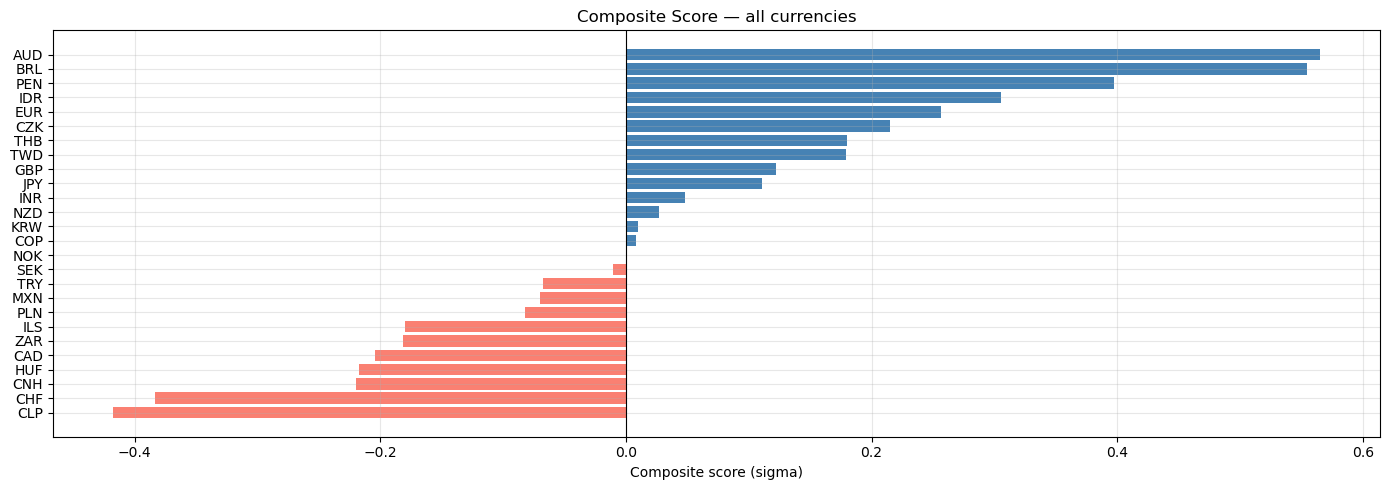

In [6]:
# Composite score bar chart — all currencies
scores = snap['score'].sort_values(ascending=True)
colors = ['steelblue' if v >= 0 else 'salmon' for v in scores]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(scores.index, scores.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Composite score (sigma)')
ax.set_title('Composite Score — all currencies')
plt.tight_layout()
plt.show()

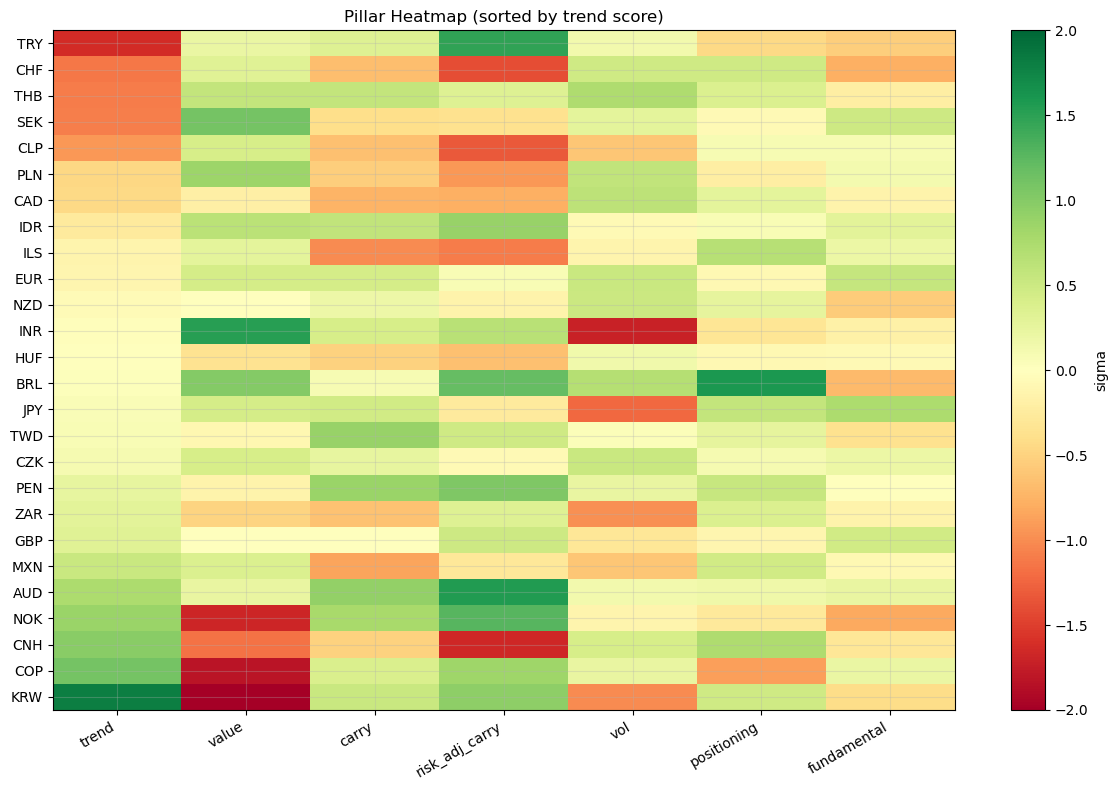

In [7]:
# Pillar heatmap — one row per currency, one column per pillar
pillar_cols = ['trend', 'value', 'carry', 'risk_adj_carry', 'vol', 'positioning', 'fundamental']
heat = snap[pillar_cols].sort_values('trend')

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=-2, vmax=2)
ax.set_xticks(range(len(pillar_cols)))
ax.set_xticklabels(pillar_cols, rotation=30, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
plt.colorbar(im, ax=ax, label='sigma')
ax.set_title('Pillar Heatmap (sorted by trend score)')
plt.tight_layout()
plt.show()

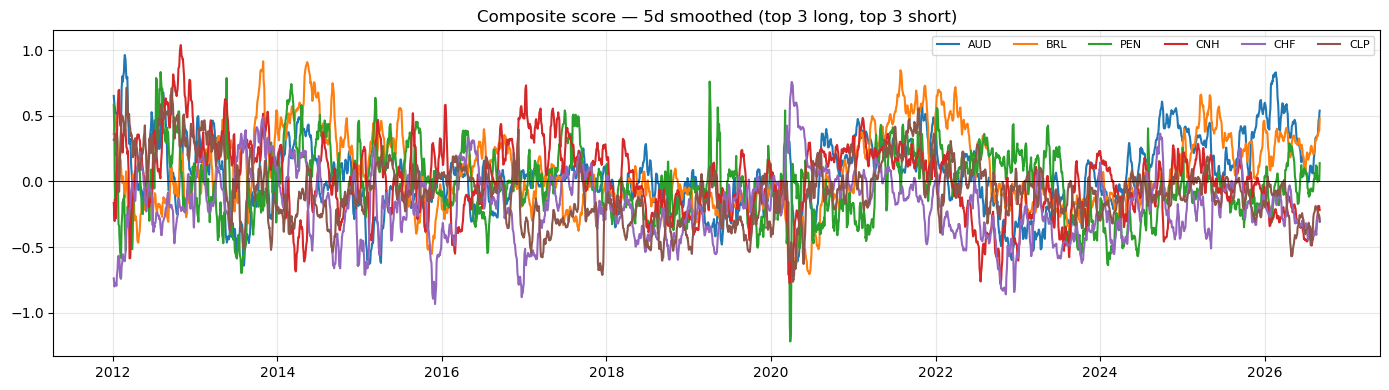

In [8]:
# Composite score history — top 6 long / short
latest = ex.history('composite').iloc[-1].sort_values(ascending=False)
top6   = list(latest.head(3).index) + list(latest.tail(3).index)

fig, ax = plt.subplots(figsize=(14, 4))
for ccy in top6:
    h = ex.history('composite', ccy).rolling(5).mean()
    ax.plot(h.index, h.values, label=ccy)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Composite score — 5d smoothed (top 3 long, top 3 short)')
ax.legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# Crosses
#ex.crosses()

---
## Pillar 1 — Trend
Vol-normalised momentum: 3m, 6m, 9m, distance from 6m MA, MACD histogram.

All sub-signals are divided by 3m realised vol before normalising, so a 5% move in a 20-vol currency and a 5% move in a 10-vol currency get equal weight.

| Sub-signal | What it measures | Weight |
|---|---|---|
| m3 | 63-day log return / RV | 1.5 |
| m6 | 126-day log return / RV | 1.5 |
| m9 | 189-day log return / RV | 1.0 |
| dist_126d | (spot / 126d MA − 1) / RV — distance from 6m moving average | 1.0 |
| macd_hist | (EMA12 − EMA26 − signal9) / spot / RV | 0.5 |

  Short/medium-term momentum is double-weighted; MACD is half-weighted (it's the fastest and noisiest).

In [10]:
ex.snapshot('trend')

,score,composite,bloc,m3,m6,m9,dist_126d,macd_hist,rank
ccy,,,,,,,,,
KRW,1.81,0.01,APAC,2.66,1.47,1.63,2.17,-0.08,1
COP,1.10,0.01,LATAM,1.48,1.37,1.20,1.36,-1.55,2
CNH,0.98,-0.22,APAC,0.53,1.28,1.88,0.97,-0.39,3
NOK,0.87,0.00,G10,0.47,1.04,1.29,0.96,0.51,4
AUD,0.75,0.56,G10,0.66,0.23,1.65,0.70,0.85,5
MXN,0.52,-0.07,LATAM,0.58,0.51,0.77,0.66,-0.43,6
GBP,0.32,0.12,G10,0.74,0.40,-0.05,0.44,-0.70,7
ZAR,0.28,-0.18,CEEMEA,0.51,0.04,0.35,0.43,-0.07,8
PEN,0.24,0.40,LATAM,0.90,0.14,-0.61,0.44,-0.19,9


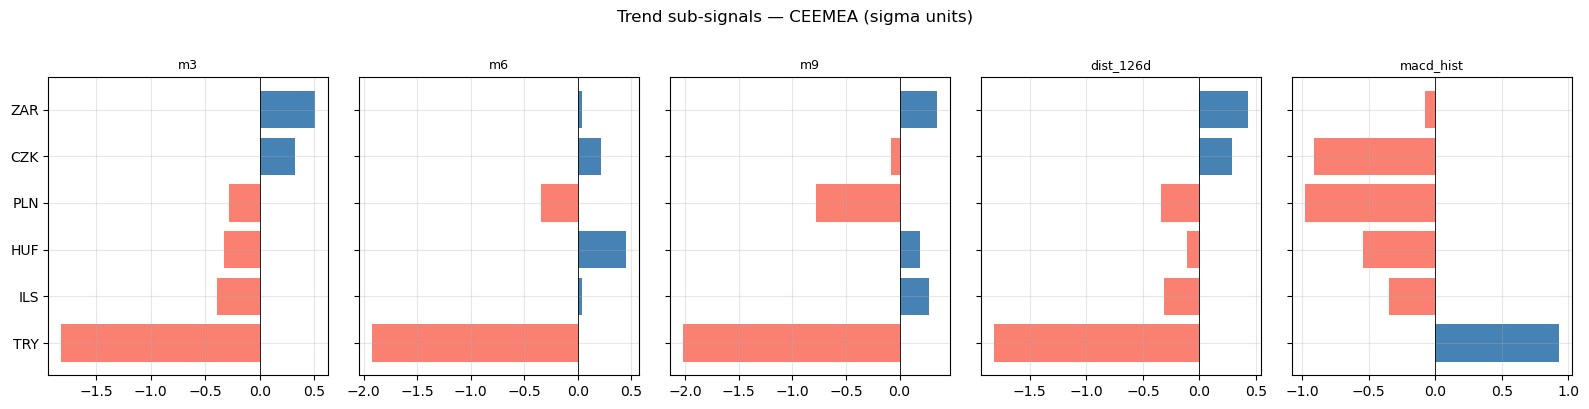

In [11]:
# Sub-signal bar chart — G10
sub_cols = ['m3', 'm6', 'm9', 'dist_126d', 'macd_hist']
vt = ex.snapshot('trend')
g10 = vt[vt.bloc == 'CEEMEA']

fig, axes = plt.subplots(1, len(sub_cols), figsize=(16, 4), sharey=True)
for ax, col in zip(axes, sub_cols):
    vals = g10[col].sort_values()
    colors = ['steelblue' if v >= 0 else 'salmon' for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(col, fontsize=9)
fig.suptitle('Trend sub-signals — CEEMEA (sigma units)', y=1.01)
plt.tight_layout()
plt.show()

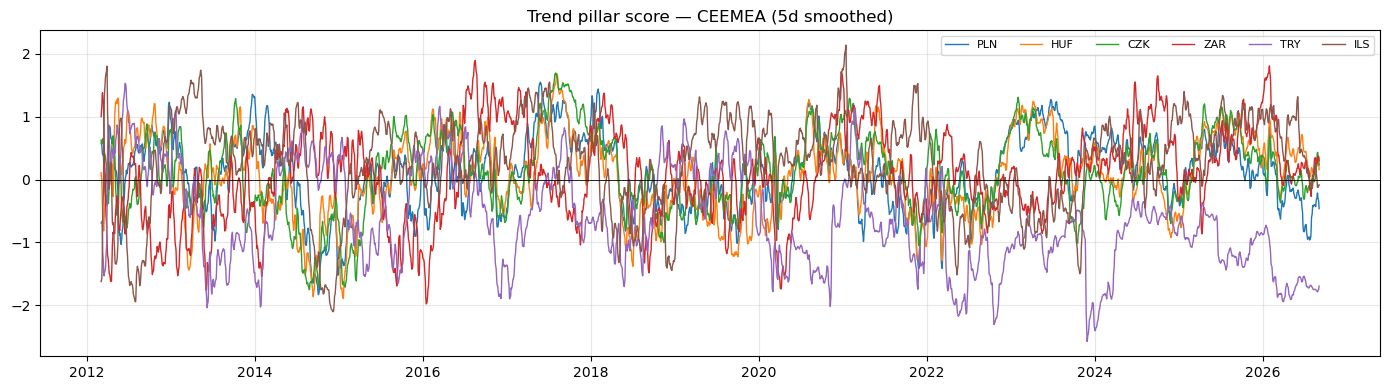

In [12]:
# Trend score history — G10
g10 = [p.ccy for p in __import__('config').CEEMEA]
fig, ax = plt.subplots(figsize=(14, 4))
for ccy in g10:
    h = ex.history('trend', ccy).rolling(5).mean()
    ax.plot(h.index, h.values, label=ccy, lw=1)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Trend pillar score — CEEMEA (5d smoothed)')
ax.legend(ncol=9, fontsize=8)
plt.tight_layout()
plt.show()

---
## Pillar 2 — Value
STEER-lite (2y window): spot ~ rate diff + ToT + credit.  
BEER-lite (3y window): REER ~ real rate diff + ToT + C/A.  
Residual sign inverted: rich = negative score.

In [13]:
ex.snapshot('value')

,score,composite,bloc,steer,beer,rank
ccy,,,,,,
INR,1.52,0.05,APAC,1.27,1.77,1
SEK,1.10,-0.01,G10,0.38,1.82,2
BRL,1.00,0.55,LATAM,1.10,0.91,3
PLN,0.85,-0.08,CEEMEA,0.56,1.14,4
IDR,0.64,0.31,APAC,0.94,0.34,5
THB,0.58,0.18,APAC,0.53,0.62,6
EUR,0.43,0.26,G10,0.68,0.19,7
JPY,0.42,0.11,G10,0.57,0.28,8
CZK,0.42,0.22,CEEMEA,0.05,0.79,9


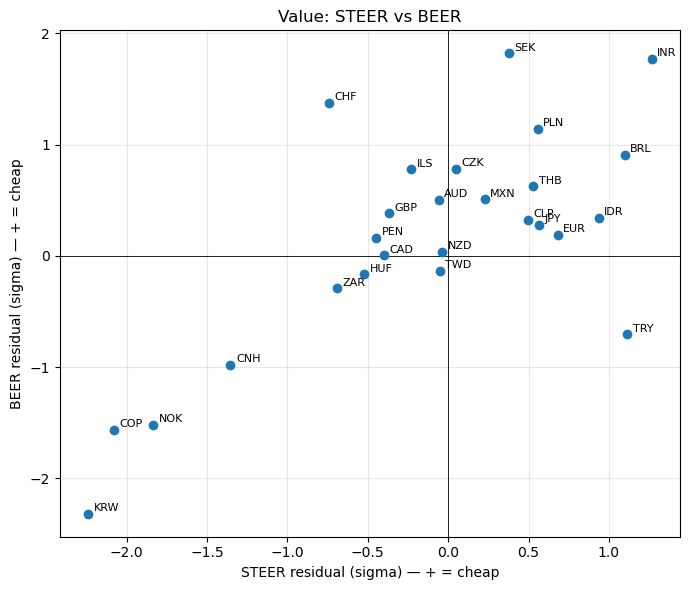

In [14]:
# STEER vs BEER scatter — data already in snapshot
vv = ex.snapshot('value')
steer = vv['steer'].dropna()
beer  = vv['beer'].dropna()
common = steer.index.intersection(beer.index)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(steer[common], beer[common], zorder=3)
for ccy in common:
    ax.annotate(ccy, (steer[ccy], beer[ccy]), fontsize=8,
                xytext=(4, 2), textcoords='offset points')
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('STEER residual (sigma) — + = cheap')
ax.set_ylabel('BEER residual (sigma) — + = cheap')
ax.set_title('Value: STEER vs BEER')
plt.tight_layout()
plt.show()

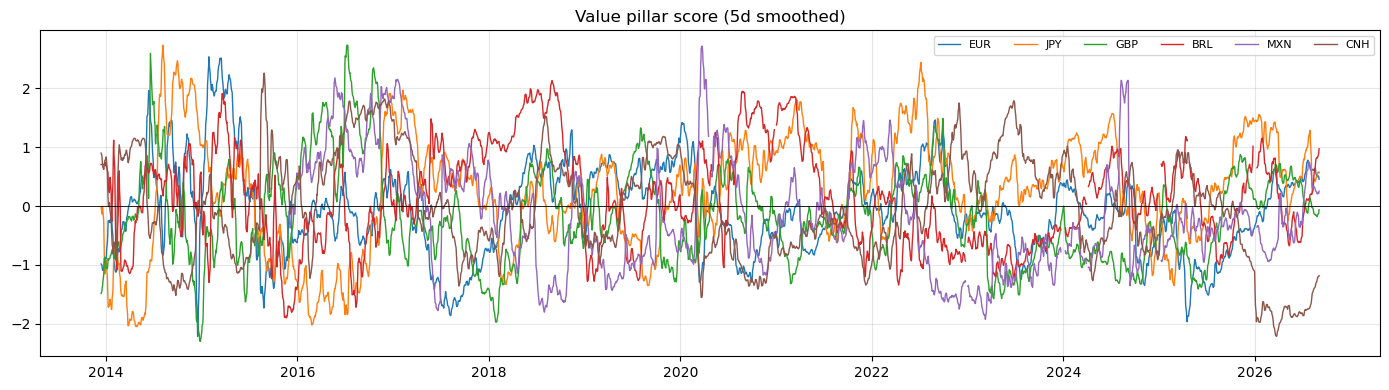

In [15]:
# Value score history — select currencies
ccys = ['EUR', 'JPY', 'GBP', 'BRL', 'MXN', 'CNH']
fig, ax = plt.subplots(figsize=(14, 4))
for ccy in ccys:
    h = ex.history('value', ccy).rolling(5).mean()
    ax.plot(h.index, h.values, label=ccy, lw=1)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Value pillar score (5d smoothed)')
ax.legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.show()

---
## Pillar 3 — Carry
Forward-implied carry (not swap rates), so NDF premium, (basis and funding in included).
Carry is (3m_forward / spot − 1) × (365/91) × 100, signed long non-USD.

| Sub-signal | What it measures | Weight |
|---|---|---:|
| carry_level | Annualised carry % | 2.0 |
| carry_slope | Carry minus its own 21-day rolling mean — is carry improving or flattening? | 1.0 |

In [16]:
s.md.carry.iloc[-1].sort_values()

CHF   -4.09
JPY   -2.83
CNH   -2.53
SEK   -2.02
CAD   -1.71
EUR   -1.42
ILS   -1.42
THB   -1.21
NZD   -0.98
KRW   -0.57
CLP   -0.31
CZK   -0.28
TWD   -0.19
PLN   -0.05
GBP   -0.04
NOK    0.50
AUD    0.62
HUF    1.29
PEN    2.02
IDR    2.71
ZAR    2.71
INR    2.87
MXN    2.88
BRL    7.58
COP    7.63
TRY   30.57
Name: 2026-09-02 00:00:00, dtype: float64

<Axes: title={'center': 'Carry %'}>

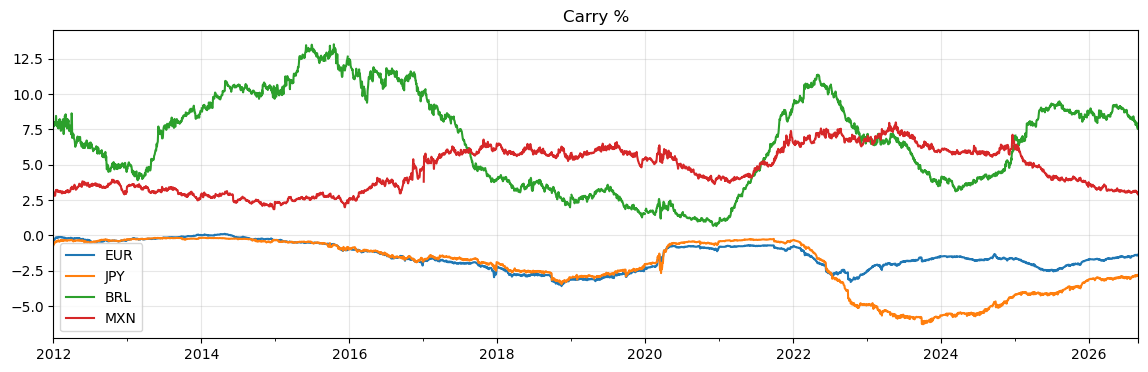

In [17]:
s.md.carry[['EUR', 'JPY', 'BRL', 'MXN']].plot(title='Carry %')

In [18]:
ex.snapshot('carry')

,score,composite,bloc,carry_level,carry_slope,rank
ccy,,,,,,
AUD,0.91,0.56,G10,1.45,-0.17,1
TWD,0.88,0.18,APAC,0.39,1.86,2
PEN,0.87,0.40,LATAM,0.61,1.40,3
NOK,0.77,0.00,G10,1.28,-0.25,4
IDR,0.58,0.31,APAC,1.02,-0.30,5
THB,0.57,0.18,APAC,0.34,1.05,6
KRW,0.53,0.01,APAC,1.05,-0.52,7
JPY,0.46,0.11,G10,0.26,0.86,8
EUR,0.42,0.26,G10,0.58,0.10,9


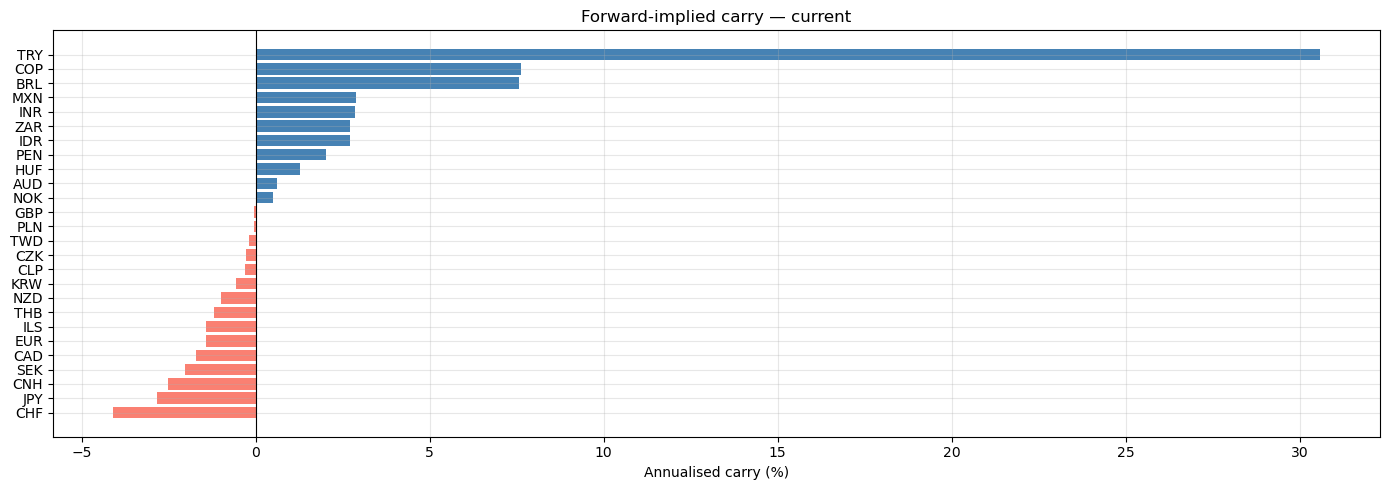

In [19]:
# Raw carry (%) — current cross-section
carry_raw = ex.raw('carry').iloc[-1].sort_values(ascending=True)
colors = ['steelblue' if v >= 0 else 'salmon' for v in carry_raw]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(carry_raw.index, carry_raw.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Annualised carry (%)')
ax.set_title('Forward-implied carry — current')
plt.tight_layout()
plt.show()

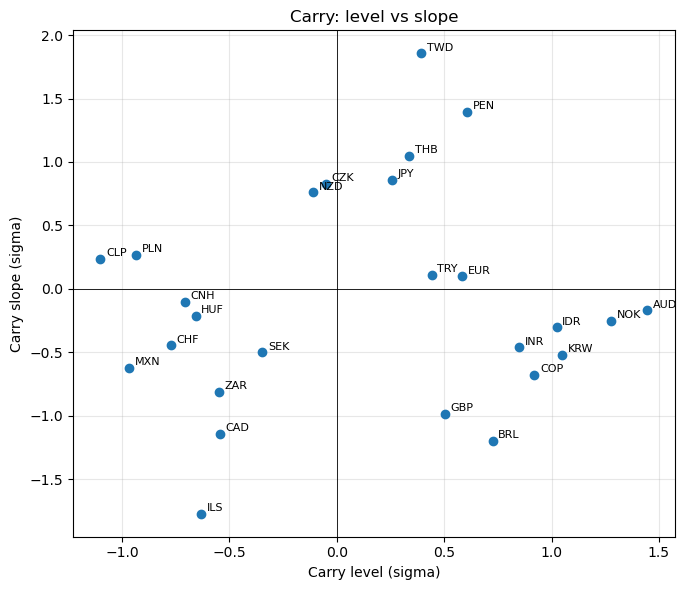

In [20]:
# Carry level vs carry slope scatter — data already in snapshot
vc = ex.snapshot('carry')
lvl   = vc['carry_level']
slope = vc['carry_slope']
common = lvl.dropna().index.intersection(slope.dropna().index)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lvl[common], slope[common], zorder=3)
for ccy in common:
    ax.annotate(ccy, (lvl[ccy], slope[ccy]), fontsize=8,
                xytext=(4, 2), textcoords='offset points')
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Carry level (sigma)')
ax.set_ylabel('Carry slope (sigma)')
ax.set_title('Carry: level vs slope')
plt.tight_layout()
plt.show()

---
# Pillar 4 — Risk-Adjusted Carry
| Sub-signal | What it measures | Weight |
|---|---|---:|
| carry_iv | carry / 3m ATM implied vol — the option market's price of risk | 1.0 |
| carry_downside | carry / downside RV (only negative daily returns, 63d rolling) — left-tail risk | 1.0 |
| carry_cds | carry / (5y CDS / 100) — sovereign credit risk compensation, mainly EM | 1.0 |

In [21]:
ex.snapshot('risk_adj_carry')

,score,composite,bloc,carry_iv,carry_downside,carry_cds,rank
ccy,,,,,,,
AUD,1.56,0.56,G10,1.51,1.60,NaN,1
TRY,1.48,-0.07,CEEMEA,1.41,1.91,1.11,2
NOK,1.28,0.00,G10,1.33,1.22,NaN,3
BRL,1.19,0.55,LATAM,0.31,2.33,0.93,4
PEN,1.03,0.40,LATAM,0.50,1.34,1.26,5
KRW,0.95,0.01,APAC,1.17,0.91,0.77,6
IDR,0.88,0.31,APAC,0.96,1.01,0.66,7
COP,0.84,0.01,LATAM,0.97,0.32,1.23,8
INR,0.64,0.05,APAC,0.73,0.19,1.00,9


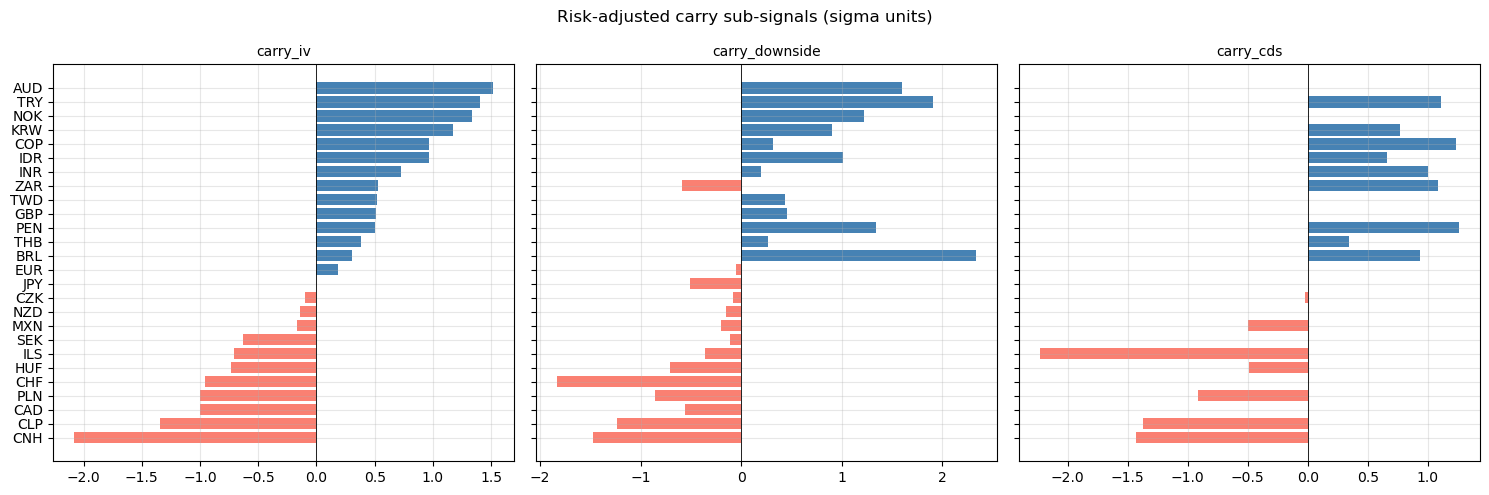

In [22]:
# Sub-signal bar chart — data already in snapshot
sub_cols = ['carry_iv', 'carry_downside', 'carry_cds']
vr = ex.snapshot('risk_adj_carry').sort_values('carry_iv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, col in zip(axes, sub_cols):
    vals = vr[col]
    colors = ['steelblue' if v >= 0 else 'salmon' for v in vals]
    ax.barh(vr.index, vals, color=colors)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(col, fontsize=10)
fig.suptitle('Risk-adjusted carry sub-signals (sigma units)')
plt.tight_layout()
plt.show()

---
# Pillar 5 — Vol Regime

The risk beta is a rolling 126-day regression of the currency's daily return against changes in HY OAS. Positive beta = haven (JPY, CHF rally when credit widens). Negative beta = risk (BRL, ZAR, AUD sell off). If **ATM vol rises 2 vol** points over a month, it hurts risk currencies 

| Sub-signal | Formula | Weight |
|---|---|---:|
| iv_change | −Δ21d(ATM vol) × beta | 1.0 |
| rv_change | −Δ21d(1m RV) × beta | 1.0 |
| term_slope | (3m ATM vol − 1m ATM vol) × \|beta\| | 0.5 |

In [23]:
ex.snapshot('vol')

,score,composite,bloc,iv_change,rv_change,term_slope,rank
ccy,,,,,,,
THB,0.72,0.18,APAC,0.82,1.06,-0.15,1
BRL,0.68,0.55,LATAM,0.55,0.00,2.32,2
CAD,0.62,-0.20,G10,0.72,1.24,-0.85,3
PLN,0.59,-0.08,CEEMEA,1.31,0.26,-0.18,4
EUR,0.52,0.26,G10,0.86,0.39,0.11,5
CZK,0.52,0.22,CEEMEA,0.70,0.35,0.47,6
NZD,0.51,0.03,G10,0.68,0.23,0.72,7
CHF,0.48,-0.38,G10,0.46,0.85,-0.20,8
CNH,0.41,-0.22,APAC,0.47,0.07,0.95,9


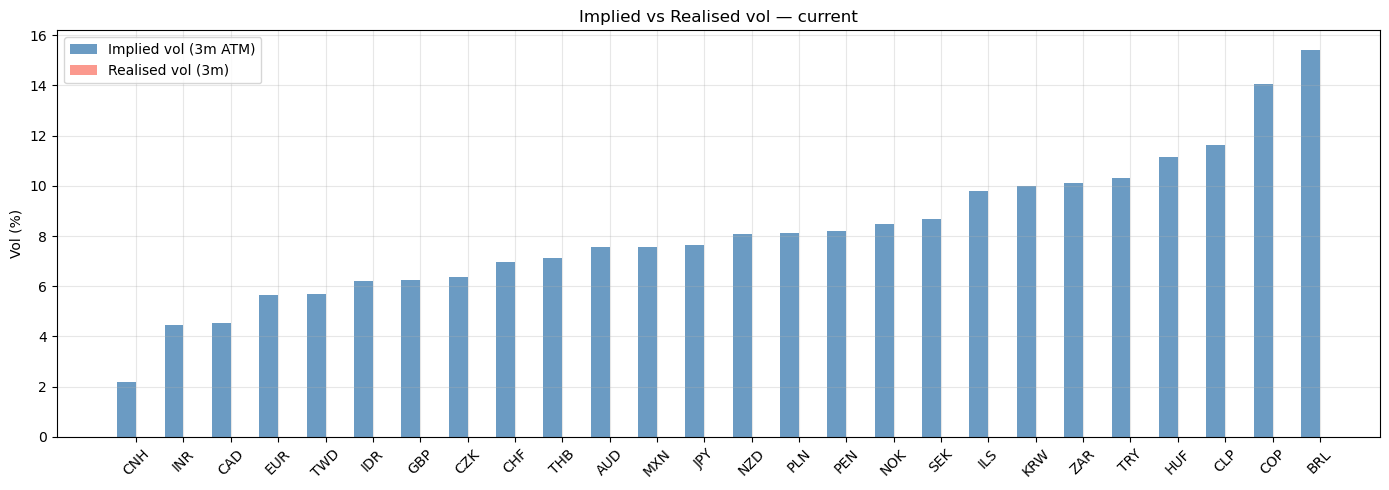

In [24]:
# IV vs RV — current levels (raw, not scored)
iv = ex.raw('atm_vol').iloc[-1].sort_values(ascending=True)
rv = ex.raw('rv_3m').reindex(iv.index).iloc[-1]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(iv))
ax.bar(x - 0.2, iv.values, 0.4, label='Implied vol (3m ATM)', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, rv.values, 0.4, label='Realised vol (3m)', color='salmon', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(iv.index, rotation=45)
ax.set_ylabel('Vol (%)')
ax.set_title('Implied vs Realised vol — current')
ax.legend()
plt.tight_layout()
plt.show()

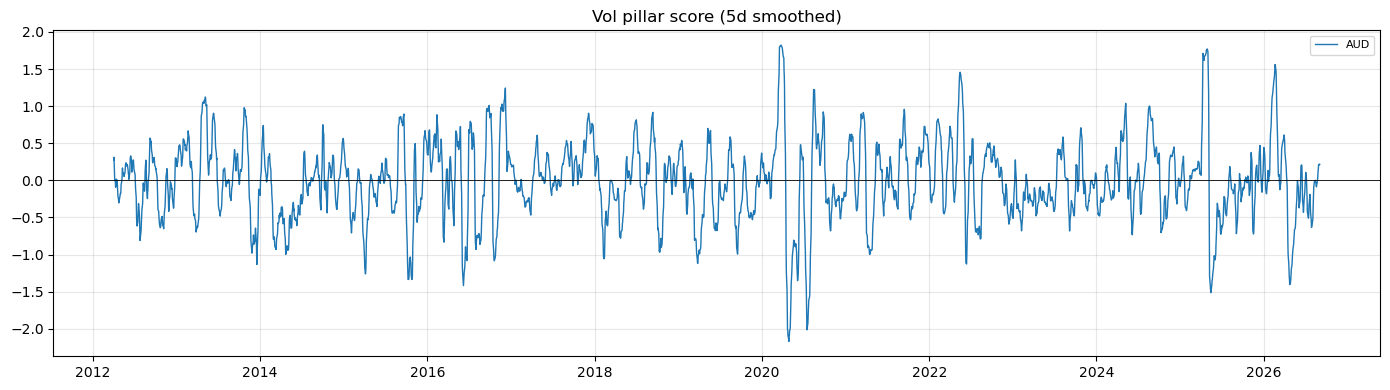

In [36]:
# Vol score history
ccys = ['AUD']
fig, ax = plt.subplots(figsize=(14, 4))
for ccy in ccys:
    h = ex.history('vol', ccy).rolling(5).mean()
    ax.plot(h.index, h.values, label=ccy, lw=1)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Vol pillar score (5d smoothed)')
ax.legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.show()

IV frame: (3828, 26)  last date: 2026-09-02 00:00:00
RV frame: (3828, 26)  last date: 2026-09-02 00:00:00
  aligned names    : 26
  RV non-NaN       : 26 / 26
  IV range         : 2.19 to 15.42
  RV range         : 0.97 to 15.10


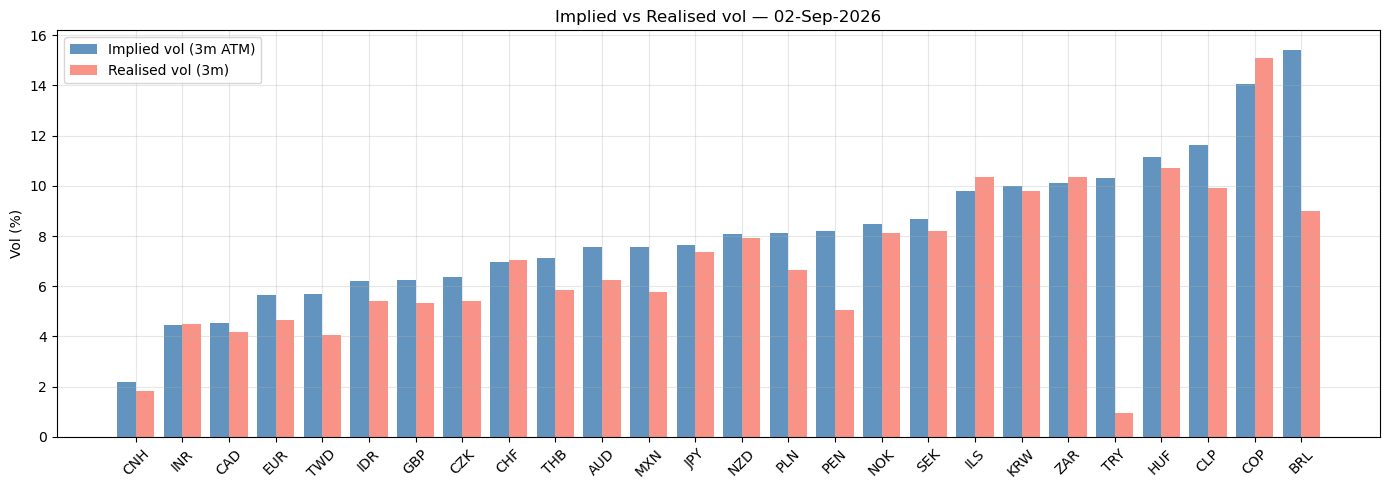


IV - RV (vol points), richest first:
TRY    9.33
BRL    6.43
PEN    3.14
MXN    1.80
CLP    1.72
TWD    1.64
PLN    1.45
AUD    1.30
THB    1.27
EUR    1.00
CZK    0.96
GBP    0.92
IDR    0.79
SEK    0.45
HUF    0.44
CAD    0.37
NOK    0.36
CNH    0.35
JPY    0.28
KRW    0.19
NZD    0.17
INR   -0.03
CHF   -0.10
ZAR   -0.20
ILS   -0.52
COP   -1.04


In [33]:
# --- IV vs RV: diagnostic + plot -------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

iv_raw = ex.raw('atm_vol')
rv_raw = ex.raw('rv_3m')

# 1. Take the LAST ROW first, then align on currency.
#    (reindexing the frame itself hits the date index, not the columns)
iv_last = iv_raw.iloc[-1]
rv_last = rv_raw.iloc[-1]

# 2. Diagnostics ------------------------------------------------------------
print(f"IV frame: {iv_raw.shape}  last date: {iv_raw.index[-1]}")
print(f"RV frame: {rv_raw.shape}  last date: {rv_raw.index[-1]}")

only_iv = iv_last.index.difference(rv_last.index)
only_rv = rv_last.index.difference(iv_last.index)
if len(only_iv): print(f"  no RV column for : {list(only_iv)}")
if len(only_rv): print(f"  no IV column for : {list(only_rv)}")

common = iv_last.index.intersection(rv_last.index)
iv = iv_last[common].dropna().sort_values()
rv = rv_last.reindex(iv.index)
print(f"  aligned names    : {len(iv)}")
print(f"  RV non-NaN       : {rv.notna().sum()} / {len(iv)}")
if rv.notna().sum() == 0:
    raise ValueError("RV is entirely NaN after alignment — check ex.raw('rv_3m')")
print(f"  IV range         : {iv.min():.2f} to {iv.max():.2f}")
print(f"  RV range         : {rv.min():.2f} to {rv.max():.2f}")

# 3. Scale guard: RV in decimals (0.089) vs IV in percent (8.9)
if rv.median() < 1 and iv.median() > 1:
    print("  >> RV looks decimal, IV percent — scaling RV x100")
    rv = rv * 100
elif iv.median() < 1 and rv.median() > 1:
    print("  >> IV looks decimal, RV percent — scaling IV x100")
    iv = iv * 100

# 4. Plot -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(iv))
ax.bar(x - 0.2, iv.values, 0.4, label='Implied vol (3m ATM)', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, rv.values, 0.4, label='Realised vol (3m)',   color='salmon',    alpha=0.85)

# mark any name where RV is missing so it isn't read as "zero vol"
for i, v in enumerate(rv.values):
    if np.isnan(v):
        ax.text(i + 0.2, iv.values[i] * 0.05, 'n/a', ha='center', va='bottom',
                fontsize=7, color='grey', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(iv.index, rotation=45)
ax.set_ylabel('Vol (%)')
ax.set_title(f"Implied vs Realised vol — {iv_raw.index[-1]:%d-%b-%Y}")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Carry table ------------------------------------------------------------
spread = (iv - rv).dropna().sort_values(ascending=False)
print("\nIV - RV (vol points), richest first:")
print(spread.round(2).to_string())

---
# Pillar 6 — Positioning
 Contrarian at extremes. Crowded longs score negative.
  For CoT currencies (G10 + MXN, BRL, ZAR):
| Sub-signal | What it measures | Weight |
|---|---|---:|
| cot_level | Net non-commercial position (L − S) — direction | 1.0 |
| cot_change | 63-day change in net — still building? More dangerous | 0.5 |
| cot_skew | Net / OI — removes noise from absolute OI changes, ranges −1 to +1 | 1.0 |

  For non-CoT currencies (rest of EM):
| Sub-signal | What it measures | Weight |
|---|---|---:|
| skew | 25d risk reversal (call premium = positive) → crowded long = call-heavy | 1.0 |
| skew_change | 21-day change in skew | 0.5 |

In [26]:
ex.snapshot('positioning')

,score,composite,bloc,cot_level,cot_change,cot_skew,skew,skew_change,rank
ccy,,,,,,,,,
BRL,1.59,0.55,LATAM,-2.62,-0.79,-1.01,1.27,2.24,1
CNH,0.72,-0.22,APAC,NaN,NaN,NaN,0.84,0.48,2
ILS,0.66,-0.18,CEEMEA,NaN,NaN,NaN,0.63,0.73,3
JPY,0.57,0.11,G10,0.38,1.88,-0.33,1.50,-1.29,4
PEN,0.55,0.40,LATAM,NaN,NaN,NaN,0.55,0.53,5
KRW,0.48,0.01,APAC,NaN,NaN,NaN,0.44,0.56,6
CHF,0.48,-0.38,G10,-0.14,-0.45,0.18,0.14,1.15,7
MXN,0.46,-0.07,LATAM,-0.79,-0.24,-0.35,0.46,0.48,8
THB,0.37,0.18,APAC,NaN,NaN,NaN,0.13,0.86,9


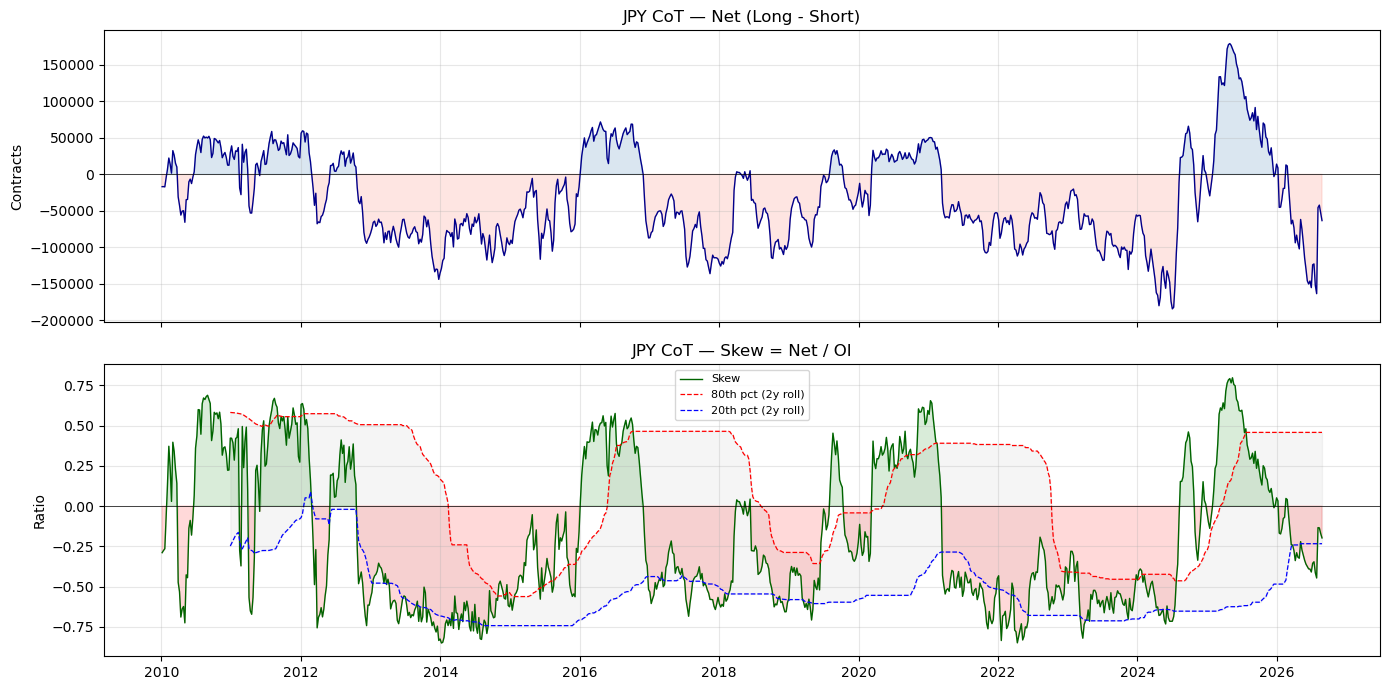

Current skew: -0.198  (60th percentile since 2010)
Net: -63,298  OI: 319,978


In [27]:
# CoT skew — one currency at a time. Change ccy here.
CCY = 'JPY'

from config import BY_CCY
import bbg
p = BY_CCY[CCY]
l = bbg.history(p.cot_long)
s_pos = bbg.history(p.cot_short)
common = l.index.intersection(s_pos.index)
net  = l.loc[common] - s_pos.loc[common]
oi   = l.loc[common] + s_pos.loc[common]
skew = net / oi.replace(0, float('nan'))

ROLL = 104
r80 = skew.rolling(ROLL, min_periods=ROLL//2).quantile(0.8)
r20 = skew.rolling(ROLL, min_periods=ROLL//2).quantile(0.2)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(net.index, net.values, color='darkblue', lw=1)
axes[0].fill_between(net.index, net.values, 0,
    where=net.values > 0, alpha=0.2, color='steelblue')
axes[0].fill_between(net.index, net.values, 0,
    where=net.values < 0, alpha=0.2, color='salmon')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title(f'{CCY} CoT — Net (Long - Short)')
axes[0].set_ylabel('Contracts')

axes[1].plot(skew.index, skew.values, color='darkgreen', lw=1, label='Skew')
axes[1].plot(r80.index, r80.values, color='red',  lw=0.9, ls='--', label='80th pct (2y roll)')
axes[1].plot(r20.index, r20.values, color='blue', lw=0.9, ls='--', label='20th pct (2y roll)')
axes[1].fill_between(skew.index, r20.values, r80.values, alpha=0.08, color='grey')
axes[1].fill_between(skew.index, skew.values, 0,
    where=skew.values > 0, alpha=0.15, color='green')
axes[1].fill_between(skew.index, skew.values, 0,
    where=skew.values < 0, alpha=0.15, color='red')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title(f'{CCY} CoT — Skew = Net / OI')
axes[1].set_ylabel('Ratio')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

last = skew.iloc[-1]
pct  = (skew <= last).mean() * 100
print(f"Current skew: {last:.3f}  ({pct:.0f}th percentile since {skew.index[0].year})")
print(f"Net: {int(net.iloc[-1]):,}  OI: {int(oi.iloc[-1]):,}")

---
# Pillar 7 — Fundamental Momentum

  Rate of change, not levels — levels are already priced through carry and value.
| Sub-signal | What it measures | Weight |
|---|---|---:|
| rate_diff_1m | Δ21d in 2y rate differential vs USD | 1.0 |
| rate_diff_3m | Δ63d in 2y rate differential vs USD | 1.0 |
| cesi_diff | Economic surprise index vs USD surprise | 1.0 |
| cds_change | Δ63d in 5y CDS (widening = negative) | 1.0 |
| tot_mom | 63-day log return of terms of trade | 0.75 |
| ca_gdp | Current account % GDP (level, not delta — structural) | 0.5 |

In [28]:
ex.snapshot('fundamental')

,score,composite,bloc,rate_diff_1m,rate_diff_3m,cesi_diff,cds_change,tot_mom,ca_gdp,rank
ccy,,,,,,,,,,
JPY,0.75,0.11,G10,0.52,0.98,1.34,NaN,NaN,0.43,1
EUR,0.55,0.26,G10,0.59,0.51,1.43,NaN,NaN,-0.14,2
SEK,0.50,-0.01,G10,0.45,0.54,0.62,NaN,NaN,0.58,3
GBP,0.45,0.12,G10,0.82,0.09,0.19,NaN,NaN,-0.93,4
IDR,0.29,0.31,APAC,-1.34,1.08,0.32,1.14,NaN,-0.77,5
AUD,0.22,0.56,G10,0.41,-0.52,-0.55,NaN,0.94,-0.96,6
COP,0.21,0.01,LATAM,0.54,-0.65,0.23,1.08,-0.25,-0.80,7
CZK,0.20,0.22,CEEMEA,0.62,0.35,0.23,-0.38,NaN,0.09,8
ILS,0.19,-0.18,CEEMEA,0.41,0.50,0.23,-0.34,NaN,0.58,9


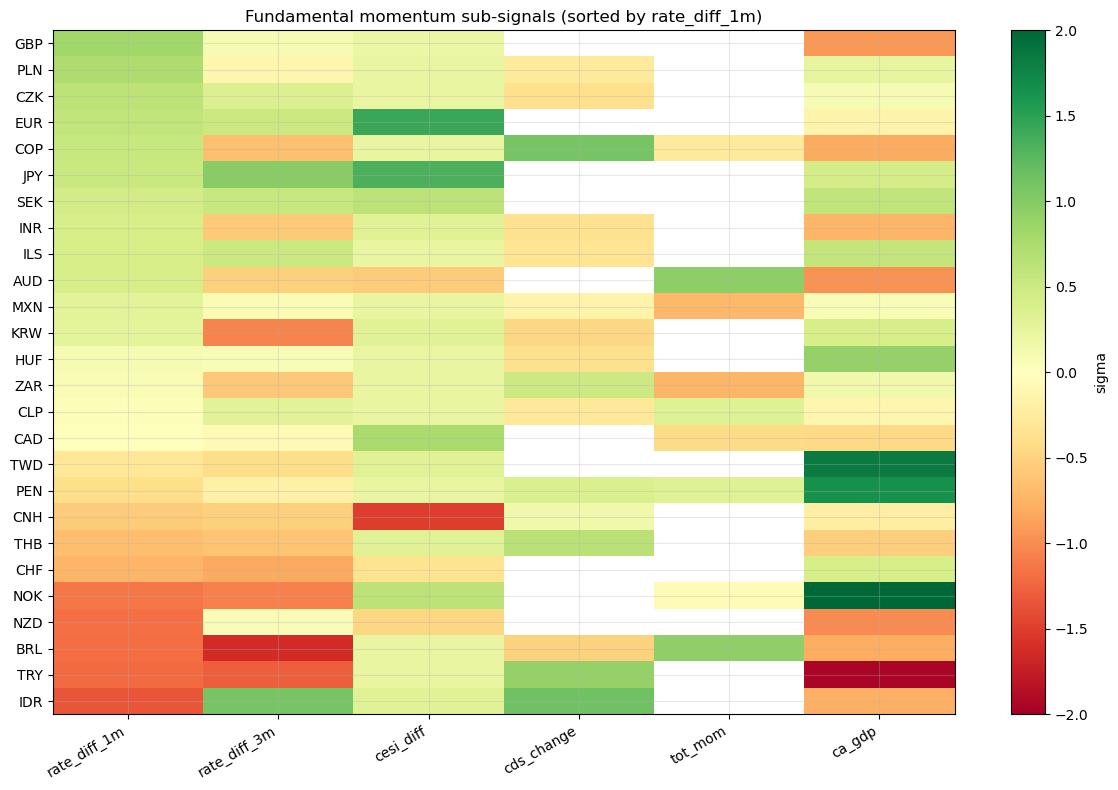

In [29]:
# Sub-signal heatmap — data already in snapshot
sub_cols = ['rate_diff_1m', 'rate_diff_3m', 'cesi_diff', 'cds_change', 'tot_mom', 'ca_gdp']
vf = ex.snapshot('fundamental')
available = [c for c in sub_cols if c in vf.columns]
df = vf[available].sort_values('rate_diff_1m', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(df.values, aspect='auto', cmap='RdYlGn', vmin=-2, vmax=2)
ax.set_xticks(range(len(available)))
ax.set_xticklabels(available, rotation=30, ha='right')
ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index)
plt.colorbar(im, ax=ax, label='sigma')
ax.set_title('Fundamental momentum sub-signals (sorted by rate_diff_1m)')
plt.tight_layout()
plt.show()

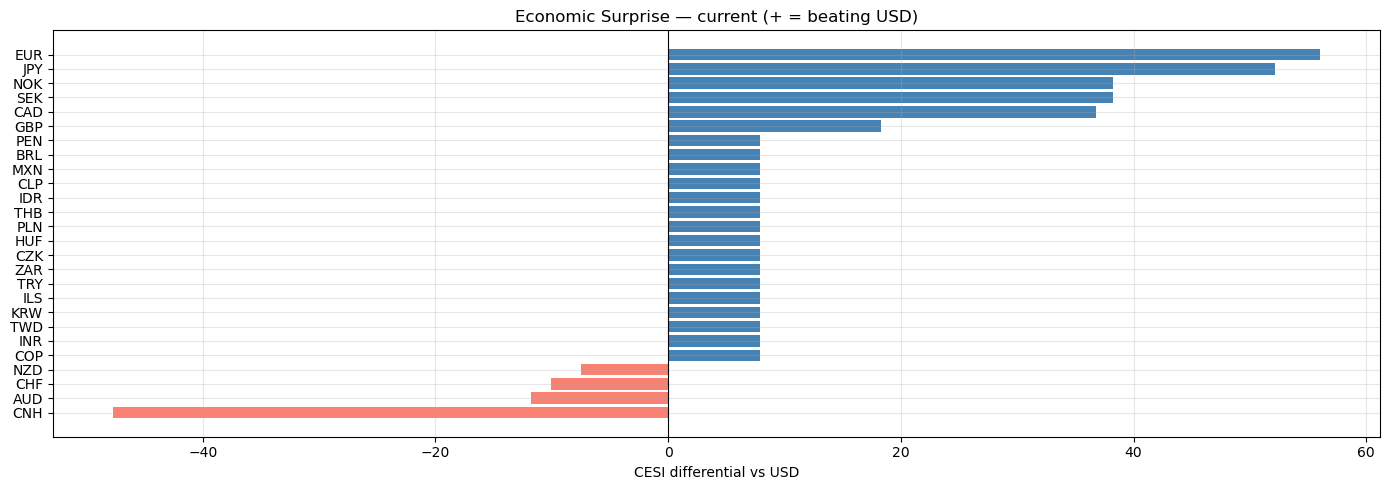

In [30]:
# CESI differential — raw, all currencies
cesi    = ex.raw('cesi')
usd_ces = ex.raw('usd_cesi').reindex(cesi.index).ffill()
diff    = cesi.sub(usd_ces, axis=0).iloc[-1].sort_values(ascending=True)

colors = ['steelblue' if v >= 0 else 'salmon' for v in diff]
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(diff.index, diff.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('CESI differential vs USD')
ax.set_title('Economic Surprise — current (+ = beating USD)')
plt.tight_layout()
plt.show()

---
## Ad-hoc exploration

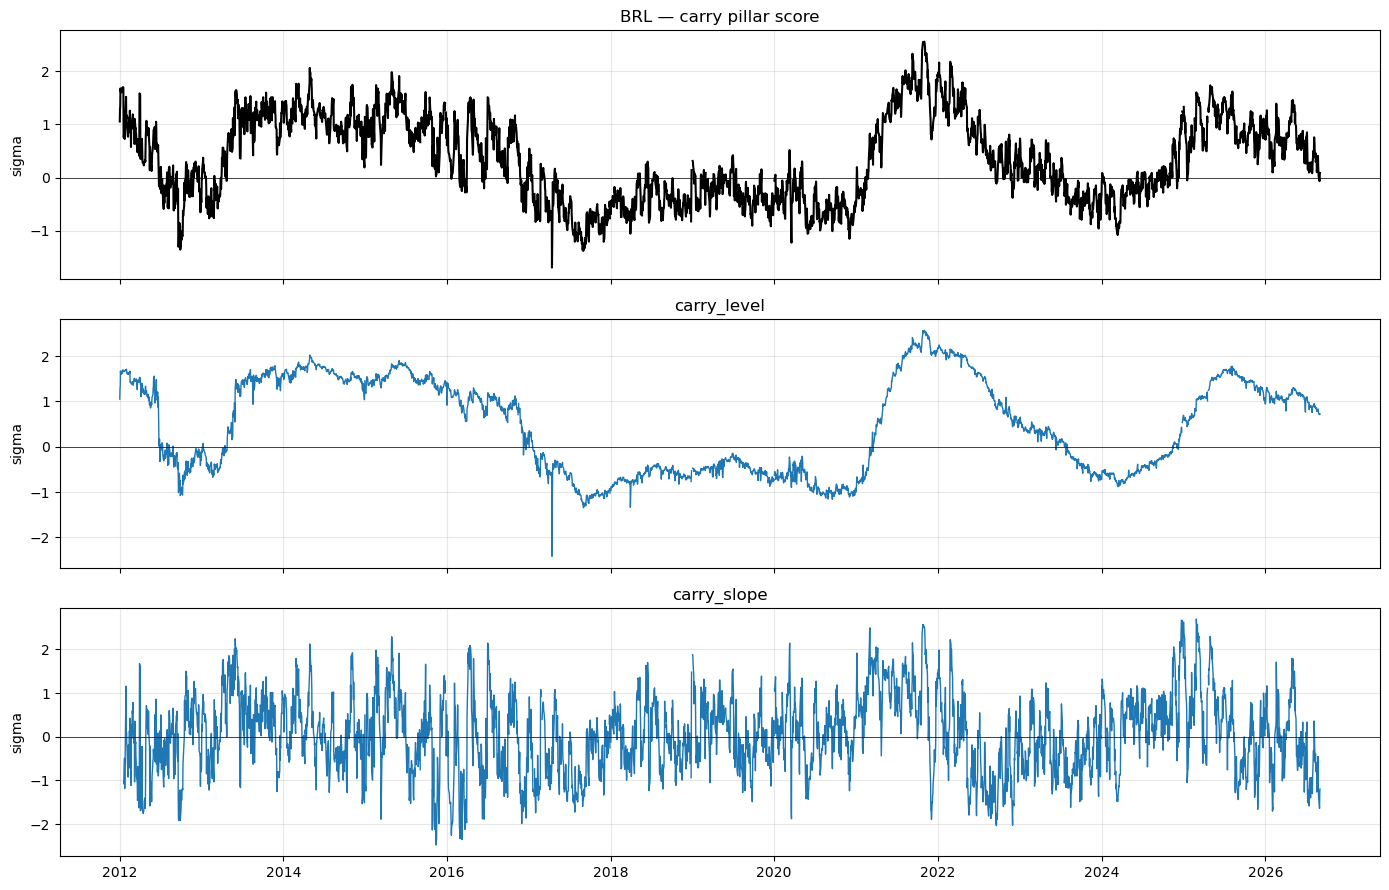

In [31]:
# Template: pick any pillar + currency and plot score history with sub-signals
PILLAR = 'carry'
CCY    = 'BRL'

score_h = ex.history(PILLAR, CCY)
comp_h  = ex.components(PILLAR)   # full-history dict

n = len(comp_h)
fig, axes = plt.subplots(n + 1, 1, figsize=(14, 3 * (n + 1)), sharex=True)
axes[0].plot(score_h.index, score_h.values, color='black', lw=1.5)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title(f'{CCY} — {PILLAR} pillar score')
axes[0].set_ylabel('sigma')

for ax, (name, panel) in zip(axes[1:], comp_h.items()):
    if CCY in panel.columns:
        ax.plot(panel.index, panel[CCY].values, lw=1)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(name)
        ax.set_ylabel('sigma')

plt.tight_layout()
plt.show()

In [32]:
# Export everything to Excel
ex.to_excel('screener_output.xlsx')

Saved -> C:\Users\CarlosCliment\OneDrive - Centile Partners Advisory Ltd\Documents\06_Models_&RISK\GitRepo\fxscreener\screener_output.xlsx


WindowsPath('C:/Users/CarlosCliment/OneDrive - Centile Partners Advisory Ltd/Documents/06_Models_&RISK/GitRepo/fxscreener/screener_output.xlsx')